---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Importance Sampling: Statistical Foundations, Variance Reduction, and Optimal Proposals

Importance sampling is a foundational Monte Carlo technique used for evaluating [expectations](expectation.ipynb) under a target probability distribution by drawing samples from an alternative **proposal distribution**. Beyond numerical integration and rare-event simulation, importance sampling provides the mathematical bedrock for **Sampled Softmax**, **Negative Sampling**, and **Off-Policy Reinforcement Learning**, where training samples originate from a biased or non-uniform data-generating stream.

This note develops the formal measure-theoretic and statistical foundations of importance sampling, proves unbiasedness, derives exact variance formulas, proves the optimal zero-variance proposal theorem, and analyzes weight degeneracy.

---

## 1\. The Monte Carlo Integration Problem

Let $(\mathcal{X}, \mathcal{F}, P)$ denote a probability space, and let $p(\mathbf{x})$ denote the [probability density function](probability-density-function.ipynb) (or probability mass function) of a [random variable](random-variables.ipynb) $\mathbf{X} \in \mathcal{X}$.

We seek to evaluate the expectation of a measurable function $f: \mathcal{X} \to \mathbb{R}$:

$$
\mu \equiv \mathbb{E}_{\mathbf{X} \sim p}[f(\mathbf{X})] = \int_{\mathcal{X}} f(\mathbf{x}) p(\mathbf{x}) d\mathbf{x}
$$

The standard naive Monte Carlo estimator draws $N$ independent samples $\mathbf{X}_1, \dots, \mathbf{X}_N \sim p(\mathbf{x})$ and computes:

$$
\hat{\mu}_{\text{MC}} = \frac{1}{N} \sum_{i=1}^N f(\mathbf{X}_i)
$$

### 1.1\. Limitations of Naive Monte Carlo

Naive Monte Carlo fails in two critical scenarios:

1. **Intractable Sampling:** Direct sampling from $p(\mathbf{x})$ is computationally difficult or closed-form density evaluation is unavailable (e.g., energy-based models, high-dimensional unnormalized partition functions).
2. **Rare Events & High Variance:** If $f(\mathbf{x})$ assumes large values primarily in regions where $p(\mathbf{x})$ is tiny (the "tails"), naive samples from $p(\mathbf{x})$ rarely land in the critical region, resulting in severe sample inefficiency and massive estimation variance.



## 2\. Importance Sampling: Change of Measure & Unbiasedness

Importance sampling overcomes these limitations by choosing an instrumental **proposal distribution** $q(\mathbf{x})$ from which sampling is straightforward and which places higher probability mass on the important regions of $f(\mathbf{x})$.

::: {#def-importance-sampling-estimator}
## Unweighted Importance Sampling Estimator
Let $q(\mathbf{x})$ be a probability density on $\mathcal{X}$ satisfying the **support condition**:

$$
q(\mathbf{x}) > 0 \quad \text{whenever } f(\mathbf{x})p(\mathbf{x}) \neq 0
$$

Define the **importance weight** (likelihood ratio / Radon-Nikodym derivative) as:

$$
w(\mathbf{x}) \equiv \frac{p(\mathbf{x})}{q(\mathbf{x})}
$$

Given $N$ i.i.d. samples $\mathbf{X}_1, \dots, \mathbf{X}_N \sim q(\mathbf{x})$, the importance sampling estimator of $\mu = \mathbb{E}_p[f(\mathbf{X})]$ is:

$$
\hat{\mu}_{\text{IS}} = \frac{1}{N} \sum_{i=1}^N f(\mathbf{X}_i) w(\mathbf{X}_i) = \frac{1}{N} \sum_{i=1}^N f(\mathbf{X}_i) \frac{p(\mathbf{X}_i)}{q(\mathbf{X}_i)}
$$
:::

::: {#thm-is-unbiased}
## Unbiasedness of the Importance Sampling Estimator
Under the support condition $\text{supp}(f \cdot p) \subseteq \text{supp}(q)$, the estimator $\hat{\mu}_{\text{IS}}$ is strictly unbiased:

$$
\mathbb{E}_{\mathbf{X} \sim q}[\hat{\mu}_{\text{IS}}] = \mu
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Theorem: Unbiasedness
Taking the expectation of the estimator with respect to the proposal distribution $q$:
$$
\begin{aligned}
\mathbb{E}_{q}[\hat{\mu}_{\text{IS}}] &= \mathbb{E}_{q}\left[ \frac{1}{N} \sum_{i=1}^N f(\mathbf{X}_i) \frac{p(\mathbf{X}_i)}{q(\mathbf{X}_i)} \right] \\
&= \frac{1}{N} \sum_{i=1}^N \mathbb{E}_{\mathbf{X}_i \sim q}\left[ f(\mathbf{X}_i) \frac{p(\mathbf{X}_i)}{q(\mathbf{X}_i)} \right] \\
&= \int_{\mathcal{X}} \left( f(\mathbf{x}) \frac{p(\mathbf{x})}{q(\mathbf{x})} \right) q(\mathbf{x}) d\mathbf{x} \\
&= \int_{\mathcal{X}} f(\mathbf{x}) p(\mathbf{x}) d\mathbf{x} = \mathbb{E}_{p}[f(\mathbf{X})] = \mu
\end{aligned}
$$
where the cancellation $\frac{p(\mathbf{x})}{q(\mathbf{x})} q(\mathbf{x}) = p(\mathbf{x})$ is valid almost everywhere on $\text{supp}(f \cdot p)$ due to the support assumption. $\blacksquare$
:::



## 3\. Variance Analysis & The Optimal Proposal Distribution

While unbiasedness is guaranteed for any valid proposal distribution $q(\mathbf{x})$, the **variance** of the estimator depends critically on the geometric alignment between $q(\mathbf{x})$ and $|f(\mathbf{x})| p(\mathbf{x})$.

::: {#thm-is-variance}
## Exact Variance of Importance Sampling
The variance of $\hat{\mu}_{\text{IS}}$ under proposal $q$ is:

$$
\text{Var}_q(\hat{\mu}_{\text{IS}}) = \frac{1}{N} \left( \int_{\mathcal{X}} \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x} - \mu^2 \right) = \frac{1}{N} \left( \mathbb{E}_{q}[f(\mathbf{X})^2 w(\mathbf{X})^2] - \mu^2 \right)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Variance Formula
Since samples $\mathbf{X}_1, \dots, \mathbf{X}_N$ are independent identically distributed draws from $q$:
$$
\text{Var}_q(\hat{\mu}_{\text{IS}}) = \text{Var}_q\left( \frac{1}{N} \sum_{i=1}^N f(\mathbf{X}_i) w(\mathbf{X}_i) \right) = \frac{1}{N} \text{Var}_q(f(\mathbf{X}) w(\mathbf{X}))
$$
By definition of variance:
$$
\text{Var}_q(f(\mathbf{X}) w(\mathbf{X})) = \mathbb{E}_q\left[ (f(\mathbf{X}) w(\mathbf{X}))^2 \right] - \left( \mathbb{E}_q[f(\mathbf{X}) w(\mathbf{X})] \right)^2
$$
Using $\mathbb{E}_q[f(\mathbf{X}) w(\mathbf{X})] = \mu$ from unbiasedness:
$$
\mathbb{E}_q\left[ f(\mathbf{X})^2 \frac{p(\mathbf{X})^2}{q(\mathbf{X})^2} \right] = \int_{\mathcal{X}} f(\mathbf{x})^2 \frac{p(\mathbf{x})^2}{q(\mathbf{x})^2} q(\mathbf{x}) d\mathbf{x} = \int_{\mathcal{X}} \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x}
$$
Subtracting $\mu^2$ and dividing by $N$ yields the result. $\blacksquare$
:::

### 3.1\. The Optimal Proposal Distribution Theorem

::: {#thm-optimal-proposal}
## Optimal Minimum-Variance Proposal Distribution
The proposal density $q^*(\mathbf{x})$ that minimizes $\text{Var}_q(\hat{\mu}_{\text{IS}})$ subject to $\int_{\mathcal{X}} q(\mathbf{x}) d\mathbf{x} = 1$ is:

$$
q^*(\mathbf{x}) = \frac{|f(\mathbf{x})| p(\mathbf{x})}{\int_{\mathcal{X}} |f(\mathbf{u})| p(\mathbf{u}) d\mathbf{u}}
$$

Furthermore, if $f(\mathbf{x}) \ge 0$ for all $\mathbf{x} \in \mathcal{X}$, the resulting variance under $q^*(\mathbf{x})$ is **identically zero**:

$$
\text{Var}_{q^*}(\hat{\mu}_{\text{IS}}) = 0
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Optimal Proposal Theorem
To minimize the integral $\int \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x}$ subject to $\int q(\mathbf{x}) d\mathbf{x} = 1$, we apply the [Cauchy-Schwarz inequality](Cauchy-Schwarz-inequality.ipynb):
$$
\left( \int_{\mathcal{X}} |f(\mathbf{x})| p(\mathbf{x}) d\mathbf{x} \right)^2 = \left( \int_{\mathcal{X}} \frac{|f(\mathbf{x})| p(\mathbf{x})}{\sqrt{q(\mathbf{x})}} \sqrt{q(\mathbf{x})} d\mathbf{x} \right)^2 \le \left( \int_{\mathcal{X}} \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x} \right) \left( \int_{\mathcal{X}} q(\mathbf{x}) d\mathbf{x} \right)
$$
Since $\int q(\mathbf{x}) d\mathbf{x} = 1$:
$$
\int_{\mathcal{X}} \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x} \ge \left( \int_{\mathcal{X}} |f(\mathbf{x})| p(\mathbf{x}) d\mathbf{x} \right)^2
$$
Equality holds if and only if $\frac{|f(\mathbf{x})| p(\mathbf{x})}{\sqrt{q(\mathbf{x})}} = c \sqrt{q(\mathbf{x})}$ for some constant $c > 0$, which requires $q(\mathbf{x}) \propto |f(\mathbf{x})| p(\mathbf{x})$. Normalizing gives $q^*(\mathbf{x}) = \frac{|f(\mathbf{x})| p(\mathbf{x})}{\int |f(\mathbf{u})| p(\mathbf{u}) d\mathbf{u}}$.

When $f(\mathbf{x}) \ge 0$, $|f(\mathbf{x})| = f(\mathbf{x})$, so $\int |f(\mathbf{u})| p(\mathbf{u}) d\mathbf{u} = \mu$. Then for every sample $\mathbf{X}_i \sim q^*$:
$$
f(\mathbf{X}_i) w(\mathbf{X}_i) = f(\mathbf{X}_i) \frac{p(\mathbf{X}_i)}{f(\mathbf{X}_i) p(\mathbf{X}_i) / \mu} = \mu
$$
Every individual sample evaluates to the exact true mean $\mu$, yielding variance $\text{Var}_{q^*}(\hat{\mu}_{\text{IS}}) = 0$. $\blacksquare$
:::

::: {.callout-warning}
## Danger of Thin-Tailed Proposals: Infinite Variance!
If $q(\mathbf{x})$ has lighter tails than $p(\mathbf{x})$, the likelihood ratio $w(\mathbf{x}) = \frac{p(\mathbf{x})}{q(\mathbf{x})}$ explodes exponentially in the tails. Consequently, the second moment $\int \frac{f(\mathbf{x})^2 p(\mathbf{x})^2}{q(\mathbf{x})} d\mathbf{x}$ diverges to $+\infty$, resulting in an estimator with **infinite variance**. Always ensure that the proposal distribution $q(\mathbf{x})$ has **heavier tails** than the target distribution $p(\mathbf{x})$.
:::



## 4\. Self-Normalized Importance Sampling (SNIS) & Effective Sample Size

In many deep learning and statistical physics applications, $p(\mathbf{x}) = \frac{\tilde{p}(\mathbf{x})}{Z_p}$ is known only up to an intractable normalizing partition function $Z_p = \int \tilde{p}(\mathbf{x}) d\mathbf{x}$.

::: {#def-snis}
## Self-Normalized Importance Sampling (SNIS)
Let $\tilde{w}_i = \frac{\tilde{p}(\mathbf{X}_i)}{q(\mathbf{X}_i)}$ be unnormalized weights for $\mathbf{X}_i \sim q(\mathbf{x})$. The SNIS estimator normalizes by the sum of weights:

$$
\hat{\mu}_{\text{SNIS}} = \frac{\sum_{i=1}^N f(\mathbf{X}_i) \tilde{w}(\mathbf{X}_i)}{\sum_{i=1}^N \tilde{w}(\mathbf{X}_i)} = \sum_{i=1}^N W_i f(\mathbf{X}_i) \quad \text{where } W_i = \frac{\tilde{w}_i}{\sum_{j=1}^N \tilde{w}_j}
$$
:::

Although $\hat{\mu}_{\text{SNIS}}$ is slightly biased for finite $N$ ($\mathbb{E}[\hat{\mu}_{\text{SNIS}}] = \mu + \mathcal{O}(1/N)$), it is **asymptotically consistent** as $N \to \infty$ by the [Law of Large Numbers](law-of-large-numbers-and-central-limit-theorem.ipynb) and Slutsky's theorem.

### 4.1\. Effective Sample Size (ESS)

When importance weights exhibit high variance, a few samples dominate the sum while the rest contribute virtually nothing (**weight degeneracy**).

::: {#def-ess}
## Effective Sample Size (ESS)
The Effective Sample Size estimates the equivalent number of independent draws from the target distribution $p$:

$$
\text{ESS} = \frac{\left( \sum_{i=1}^N w_i \right)^2}{\sum_{i=1}^N w_i^2} = \frac{1}{\sum_{i=1}^N W_i^2} \approx \frac{N}{1 + \text{Var}_q(w)}
$$

* If all weights are uniform ($W_i = 1/N$), $\text{ESS} = N$ (maximum statistical efficiency).
* If one weight dominates ($W_1 = 1, W_{i>1} = 0$), $\text{ESS} = 1$ (complete sample collapse).
:::



## 5\. PyTorch Numerical Simulations

We implement a PyTorch simulation evaluating:
1. Rare-event tail expectation: Naive Monte Carlo vs Importance Sampling.
2. Variance comparison and empirical convergence rate.
3. Demonstration of Effective Sample Size collapse under misaligned proposal.


Executing Importance Sampling simulations on: cuda


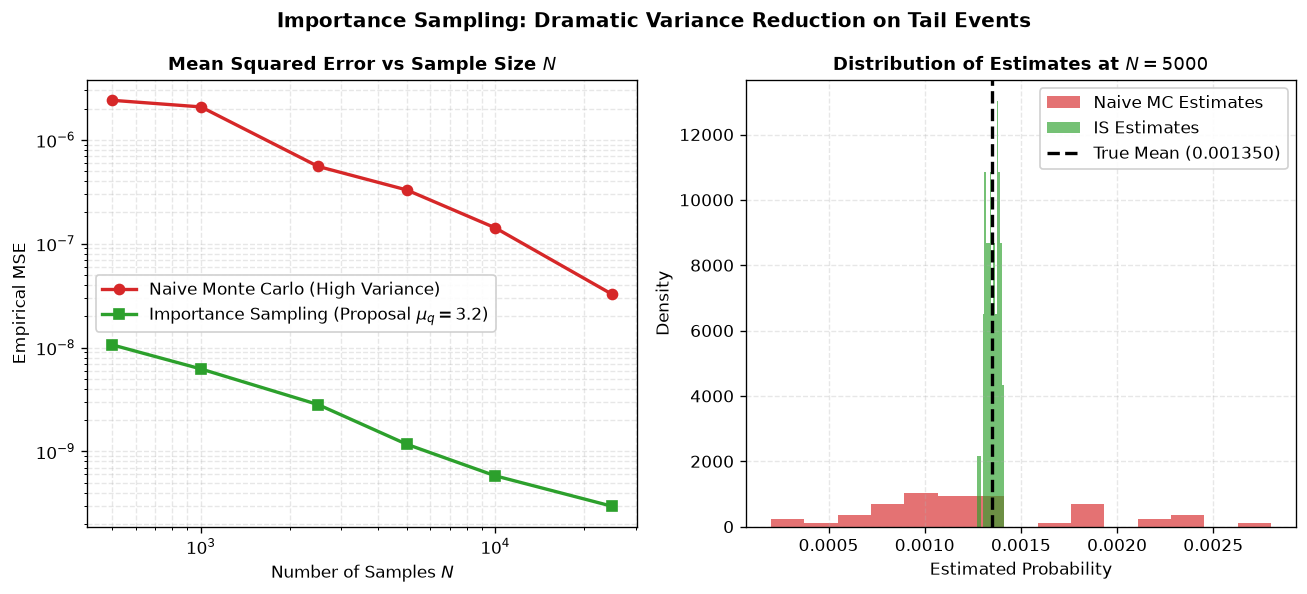

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Importance Sampling simulations on: {device}")

# Problem: Estimate E_p[f(X)] where X ~ N(0, 1) and f(x) = I(x > 3.0) (Tail probability P(X > 3.0))
# Analytical Ground Truth: 1 - Phi(3.0) approx 0.001349898
true_val = 0.00134989803163

# Method 1: Naive Monte Carlo (draw from p = N(0, 1))
def run_naive_mc(N_samples):
    X = torch.randn(N_samples, device=device)
    f_X = (X > 3.0).float()
    est = torch.mean(f_X).item()
    return est

# Method 2: Importance Sampling with shifted proposal q = N(mu_q=3.2, sigma_q=1.0)
def run_importance_sampling(N_samples, mu_q=3.2, sigma_q=1.0):
    # Draw from q(x)
    X = torch.randn(N_samples, device=device) * sigma_q + mu_q
    
    # Target density p(x) and Proposal density q(x)
    log_p = -0.5 * X**2 - 0.5 * np.log(2 * np.pi)
    log_q = -0.5 * ((X - mu_q) / sigma_q)**2 - np.log(sigma_q) - 0.5 * np.log(2 * np.pi)
    
    weights = torch.exp(log_p - log_q)
    f_X = (X > 3.0).float()
    
    est = torch.mean(f_X * weights).item()
    # Compute Effective Sample Size (ESS)
    normalized_weights = weights / torch.sum(weights)
    ess = (1.0 / torch.sum(normalized_weights**2)).item()
    return est, ess

# Run repeated experiments across sample sizes N
sample_sizes = [500, 1000, 2500, 5000, 10000, 25000]
trials = 50

mc_results = {N: [] for N in sample_sizes}
is_results = {N: [] for N in sample_sizes}

torch.manual_seed(42)
for N in sample_sizes:
    for _ in range(trials):
        mc_results[N].append(run_naive_mc(N))
        est_is, _ = run_importance_sampling(N)
        is_results[N].append(est_is)

# Calculate empirical MSE
mc_mse = [np.mean((np.array(mc_results[N]) - true_val)**2) for N in sample_sizes]
is_mse = [np.mean((np.array(is_results[N]) - true_val)**2) for N in sample_sizes]

# Plot MSE comparison on log-log scale
plt.figure(figsize=(11, 5), dpi=120)

plt.subplot(1, 2, 1)
plt.loglog(sample_sizes, mc_mse, 'o-', label='Naive Monte Carlo (High Variance)', color='#d62728', lw=2)
plt.loglog(sample_sizes, is_mse, 's-', label=r'Importance Sampling (Proposal $\mu_q=3.2$)', color='#2ca02c', lw=2)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.title('Mean Squared Error vs Sample Size $N$', fontsize=11, fontweight='bold')
plt.xlabel('Number of Samples $N$', fontsize=10)
plt.ylabel('Empirical MSE', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)

# Plot distribution of estimates at N=5000
plt.subplot(1, 2, 2)
plt.hist(mc_results[5000], bins=15, alpha=0.65, label='Naive MC Estimates', color='#d62728', density=True)
plt.hist(is_results[5000], bins=15, alpha=0.65, label='IS Estimates', color='#2ca02c', density=True)
plt.axvline(true_val, color='k', linestyle='--', lw=2, label=f'True Mean ({true_val:.6f})')
plt.title('Distribution of Estimates at $N = 5000$', fontsize=11, fontweight='bold')
plt.xlabel('Estimated Probability', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.suptitle('Importance Sampling: Dramatic Variance Reduction on Tail Events', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
> 
> * Robert, Christian P., and George Casella. *Monte Carlo Statistical Methods*, Springer, 2004. Chapter 3: Importance Sampling.
> * Bengio, Yoshua, and Jean-Sébastien Sénécal. "Adaptive importance sampling to accelerate training of a neural probabilistic language model." *IEEE Transactions on Neural Networks* 19.4 (2008): 713-722.
> * Owen, Art B. *Monte Carlo theory, methods and examples*, Stanford University, 2013.
